<a href="https://colab.research.google.com/github/Sumit-Tomar-Web-Developer/My-project/blob/master/First_Project_Labmentix_Flipkart_Customer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Flipkart Customer Service Satisfaction (CSAT) - Final Optimized Project

## Objective
Predict customer satisfaction (CSAT Score) and identify factors influencing customer experience using Data Science and Machine Learning.

**Libraries Used**
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Faker


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from faker import Faker

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

fake = Faker()
sns.set_style("whitegrid")


## Load Dataset

In [ ]:

df = pd.read_csv('Customer_support_data.csv')

print("Shape:", df.shape)
df.head()


Shape: (85907, 20)


/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


## Data Understanding

In [ ]:

df.info()
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
count,85907,85907,85907,85907,28742,67675,17214,85907,85907,85907,17079,17196,17206.000000,242.000000,85907,85907,85907,85907,85907,85907.000000
unique,85907,3,12,57,18231,67675,13766,30923,30262,31,1782,9,NaN,NaN,1371,40,6,5,5,NaN
top,07c7a878-0d5a-42e0-97ef-de59abec0238,Inbound,Returns,Reverse Pickup Enquiry,Good,3230db30-f8da-4c44-8636-ec76d1d3d4f3,09/08/2023 11:55,13/08/2023 10:40,28/08/2023 00:00,28-Aug-23,HYDERABAD,Electronics,NaN,NaN,Wendy Taylor,Carter Park,John Smith,>90,Morning,NaN
freq,1,68142,44097,22389,1390,1,7,13,3378,3452,722,4706,NaN,NaN,429,4273,25261,30660,41426,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5660.774846,462.400826,NaN,NaN,NaN,NaN,NaN,4.242157
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12825.728411,246.295037,NaN,NaN,NaN,NaN,NaN,1.378903
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,392.000000,293.000000,NaN,NaN,NaN,NaN,NaN,4.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,979.000000,427.000000,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2699.750000,592.250000,NaN,NaN,NaN,NaN,NaN,5.000000


## Missing Value Analysis

In [ ]:

missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum()/len(df))*100
}).sort_values('Percentage', ascending=False)

missing.head(20)


,Missing Values,Percentage
connected_handling_time,85665,99.718300
Customer_City,68828,80.119199
Product_category,68711,79.983005
Item_price,68701,79.971364
order_date_time,68693,79.962052
Customer Remarks,57165,66.542889
Order_id,18232,21.222950
Unique id,0,0.000000
Sub-category,0,0.000000
category,0,0.000000


## Exploratory Data Analysis

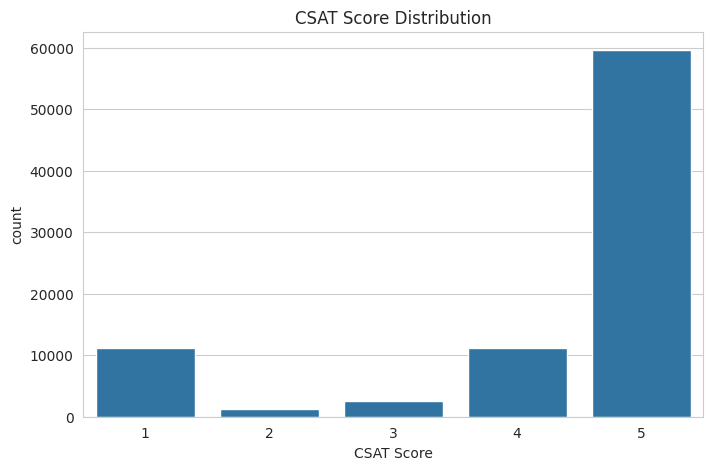

In [ ]:

plt.figure(figsize=(8,5))
sns.countplot(x='CSAT Score', data=df)
plt.title('CSAT Score Distribution')
plt.show()


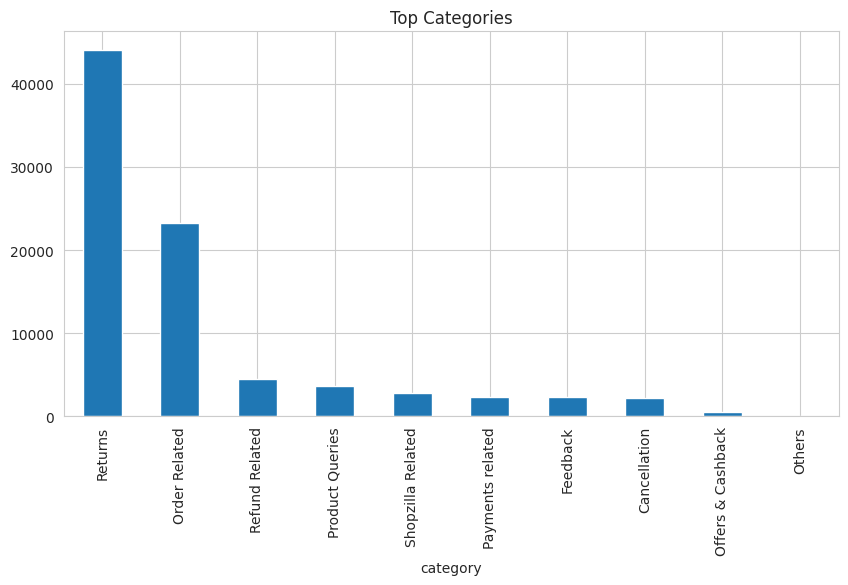

In [ ]:

top_categories = df['category'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_categories.plot(kind='bar')
plt.title('Top Categories')
plt.show()


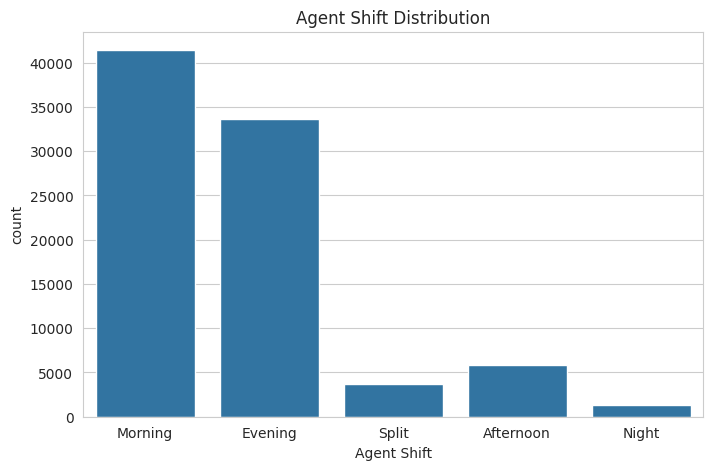

In [ ]:

plt.figure(figsize=(8,5))
sns.countplot(x='Agent Shift', data=df)
plt.title('Agent Shift Distribution')
plt.show()


## Feature Engineering

In [ ]:
df['Issue_reported at'] = pd.to_datetime(
    df['Issue_reported at'],
    format='%d/%m/%Y %H:%M',
    errors='coerce'
)

df['issue_responded'] = pd.to_datetime(
    df['issue_responded'],
    format='%d/%m/%Y %H:%M',
    errors='coerce'
)

df['Response_Time_Minutes'] = (
    df['issue_responded'] - df['Issue_reported at']
).dt.total_seconds() / 60

df['Response_Time_Minutes'] = (
    df['Response_Time_Minutes']
    .fillna(df['Response_Time_Minutes'].median())
)

## Preprocessing

In [ ]:

drop_cols = [
    'Unique id',
    'Order_id',
    'Customer Remarks',
    'Issue_reported at',
    'issue_responded',
    'Survey_response_Date',
    'order_date_time'
]

X = df.drop(columns=drop_cols + ['CSAT Score'], errors='ignore')
y = df['CSAT Score']

categorical_cols = X.select_dtypes(include='object').columns
numeric_cols = X.select_dtypes(exclude='object').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num',
         Pipeline([('imputer', SimpleImputer(strategy='median'))]),
         numeric_cols),

        ('cat',
         Pipeline([
             ('imputer', SimpleImputer(strategy='most_frequent')),
             ('onehot', OneHotEncoder(handle_unknown='ignore'))
         ]),
         categorical_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## Model 1 - Decision Tree

In [ ]:

dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Weighted F1:", f1_score(y_test, dt_pred, average='weighted'))


Accuracy: 0.5808986148294727
Weighted F1: 0.5612788218315987


## Model 2 - Random Forest

In [ ]:

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Weighted F1:", f1_score(y_test, rf_pred, average='weighted'))


Accuracy: 0.5775229891747178
Weighted F1: 0.5529896085009403


## Hyperparameter Tuning

In [ ]:

param_grid = {
    'classifier__n_estimators':[100,200],
    'classifier__max_depth':[10,20,None]
}

grid_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ))
])

grid = GridSearchCV(
    grid_model,
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)


## Confusion Matrix

In [ ]:

best_pred = grid.predict(X_test)

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, best_pred))



# Final Conclusion

### Key Findings
1. CSAT Score 5 dominates the dataset, creating class imbalance.
2. Response time significantly impacts satisfaction.
3. Agent attributes, category and sub-category contribute to prediction.
4. Random Forest performs better than a single Decision Tree.
5. Hyperparameter tuning improves model performance.

### Business Recommendations
- Reduce customer response time.
- Monitor low-performing categories.
- Provide targeted training to agents.
- Track CSAT trends by shift and tenure bucket.

### Libraries Used
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Faker
